In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [24]:
import os

In [25]:
import kagglehub
path = kagglehub.dataset_download("saurabhshahane/cyberbullying-dataset")

100%|██████████| 64.9M/64.9M [00:00<00:00, 164MB/s]

Extracting files...


In [189]:
file_path = os.path.join(path , 'youtube_parsed_dataset.csv')
os.listdir(path)

['kaggle_parsed_dataset.csv',
 'twitter_parsed_dataset.csv',
 'youtube_parsed_dataset.csv',
 'attack_parsed_dataset.csv',
 'toxicity_parsed_dataset.csv',
 'twitter_racism_parsed_dataset.csv',
 'twitter_sexism_parsed_dataset.csv',
 'aggression_parsed_dataset.csv']

In [190]:
df = pd.read_csv(file_path)
df.head()

,index,UserIndex,Text,Number of Comments,Number of Subscribers,Membership Duration,Number of Uploads,Profanity in UserID,Age,oh_label
0,0,X1,Does N.e.bodyelse Hear her Crazy ass Screamin ...,10,1,3,3,0,15,0
1,1,X2,There are so many things that are incorrect wi...,3,0,6,5,0,31,0
2,2,X3,3:26 hahah my boyfriend showed this song to me...,7,0,3,5,0,43,1
3,3,X2218,dick beyonce fuck y a ass hole you are truely ...,34,0,3,5,0,44,1
4,4,X5,DongHaeTaemin and Kai ;A; luhansehun and bacon...,11,173,5,5,0,21,0


In [191]:
print(df['Text'][3])

dick beyonce fuck y a ass hole you are truely a dog bitch Pha looks like a DIKK god you make me sick what is fu*k is this ? bad he looks like chris martin just shitier bitch nude pic pls garbage like the hole in your mother's hi how to do hand writing on goodreader? suck your own dick what is this mother fucking song all about? bitch she is a man bitch gwen shity travis hahaha i dont think hanns zimmer's needs remix a waste of time. that is a whale best video ever! bs shit billie piper you whore Billie want to make it to Britney give Billie a chance because she wants to be Britney I want Billie Piper because she is a whore I want Billie the whore Call girl is a whore PH is real ugly what's f*king with rihanna right now? bitch gone crazy bitch gone crazy hate the red hair you will suck tom yorke's ass when he farts you're da fuq


In [192]:
df = df.drop(['index', 'UserIndex'], axis=1)
df.head()

,Text,Number of Comments,Number of Subscribers,Membership Duration,Number of Uploads,Profanity in UserID,Age,oh_label
0,Does N.e.bodyelse Hear her Crazy ass Screamin ...,10,1,3,3,0,15,0
1,There are so many things that are incorrect wi...,3,0,6,5,0,31,0
2,3:26 hahah my boyfriend showed this song to me...,7,0,3,5,0,43,1
3,dick beyonce fuck y a ass hole you are truely ...,34,0,3,5,0,44,1
4,DongHaeTaemin and Kai ;A; luhansehun and bacon...,11,173,5,5,0,21,0


In [193]:
df.shape

(3464, 8)

In [194]:
x = df.drop(['oh_label'], axis=1)
y = df['oh_label']

In [195]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [196]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [197]:
import spacy

In [198]:
from spacy.lang.en.stop_words import STOP_WORDS

In [199]:
scaler = StandardScaler()
vector = TfidfVectorizer(max_features=100)

# Without Stop word filtering

In [200]:
from sklearn.model_selection import train_test_split

In [201]:
xtn , xt , ytn, yt = train_test_split(x , y, random_state=40)

In [202]:
x_train , x_val , y_train , y_val = train_test_split(xtn , ytn , random_state=40)

In [203]:
x_text = x_train['Text']
x_num = x_train.drop(['Text'], axis=1)

In [208]:
len(str(x_text[3279
               ]).split())

77

In [205]:
nlp = spacy.load('en_core_web_sm')
def filterText(text):
    # Ensure it's a string
    text = str(text).lower()
    doc = nlp(text)
    # Filter tokens
    return " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])


In [206]:
# This runs the function on every row individually
x_train['Text'] = x_train['Text'].apply(filterText)
x_val['Text'] = x_val['Text'].apply(filterText)

# Now update your x_text for the vectorizer
x_text = x_train['Text']

In [209]:
len(str(x_text[3279]).split())

77

In [210]:
x_scaled = scaler.fit_transform(x_num)
x_vec = vector.fit_transform(x_text)

In [211]:
x_train.shape

(1948, 7)

In [212]:
x_scaled.shape

(1948, 6)

In [213]:
type(y_train)

pandas.core.series.Series

In [214]:
type(x_scaled)

numpy.ndarray

In [215]:
print(type(x_vec))
print(np.array(x_vec).shape)

<class 'scipy.sparse._csr.csr_matrix'>
()


In [216]:
x_val_scaled = scaler.transform(x_val.drop(['Text'], axis=1))
x_val_vec = vector.transform(x_val['Text'])

In [217]:
from scipy.sparse import csr_matrix, hstack

x_comb = hstack([csr_matrix(x_scaled), x_vec])
x_comb.shape

(1948, 106)

In [218]:
from scipy.sparse import csr_matrix
x_val_comb = hstack([csr_matrix(x_val_scaled), x_val_vec])

In [219]:
def createTensor(x , y):
  x = x.toarray()
  xt = torch.tensor(x, dtype=torch.float32)
  yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
  return xt , yt

In [220]:
x_val_tensor , y_val_tensor= createTensor(x_val_comb , y_val.to_numpy())

In [221]:
type(y_train)

pandas.core.series.Series

In [222]:
x_train_tensor , y_train_tensor= createTensor(x_comb , y_train.to_numpy())

In [223]:
x_train_tensor.shape

torch.Size([1948, 106])

In [224]:
y_train_tensor.shape

torch.Size([1948, 1])

In [225]:
import torch.nn as nn
from torch.optim import Adam

In [234]:
class Model(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(106 , 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(32,1)

    )

  def forward(self , x):
    return self.network(x)

In [235]:
model = Model()
creterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [240]:
train_losses = []
val_losses = []

for epoch in range(80):

    # ---- TRAIN ----
    model.train()
    optimizer.zero_grad()

    logits = model(x_train_tensor)
    loss = creterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    train_loss = loss.item()

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_logits = model(x_val_tensor)
        val_loss = creterion(val_logits, y_val_tensor)

    train_losses.append(train_loss)
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

Epoch 0: Train Loss = 0.2571, Val Loss = 0.3965
Epoch 10: Train Loss = 0.2591, Val Loss = 0.4008
Epoch 20: Train Loss = 0.2537, Val Loss = 0.4044
Epoch 30: Train Loss = 0.2470, Val Loss = 0.4098
Epoch 40: Train Loss = 0.2443, Val Loss = 0.4133
Epoch 50: Train Loss = 0.2398, Val Loss = 0.4173
Epoch 60: Train Loss = 0.2357, Val Loss = 0.4228
Epoch 70: Train Loss = 0.2305, Val Loss = 0.4280


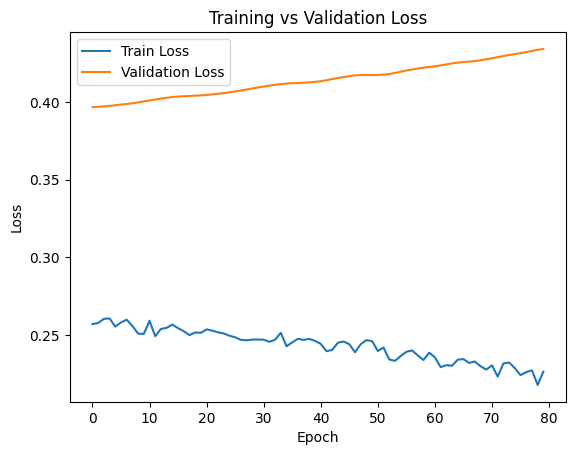

In [241]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()